# **Evaluación del Modelo**

---



Importar librerias

In [ ]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse

from sklearn.metrics import confusion_matrix

Cargamos modelo y encoder

In [ ]:
X_test = sparse.load_npz("X_test_tfidf.npz")

y_test = pd.read_csv("y_test.csv").squeeze()

modelo = joblib.load("modelo_logistic_regression.pkl")

encoder = joblib.load("label_encoder.pkl")

Obtener Predicciones

In [ ]:
y_pred = modelo.predict(X_test)

Creamos matriz de confusión

In [ ]:
cm = confusion_matrix(y_test, y_pred)

Vemos matriz numérica

In [ ]:
cm

array([[313,   0,   0,   0,   0,   0,   0,   7,   0],
       [ 11, 267,   0,   0,   0,   0,   2,   0,   0],
       [  2,   1,  55,   0,   0,   0,   0,   0,   2],
       [  2,   0,   0, 178,   0,   0,   0,   0,   0],
       [  3,   0,   0,   0,  37,   0,   0,   0,   0],
       [  2,   0,   0,   0,   0, 137,   0,   1,   0],
       [ 26,   0,   0,   0,   0,   0, 214,   0,   0],
       [ 10,   1,   0,   0,   0,   0,   0, 229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 100]])

Visualizamos Matriz

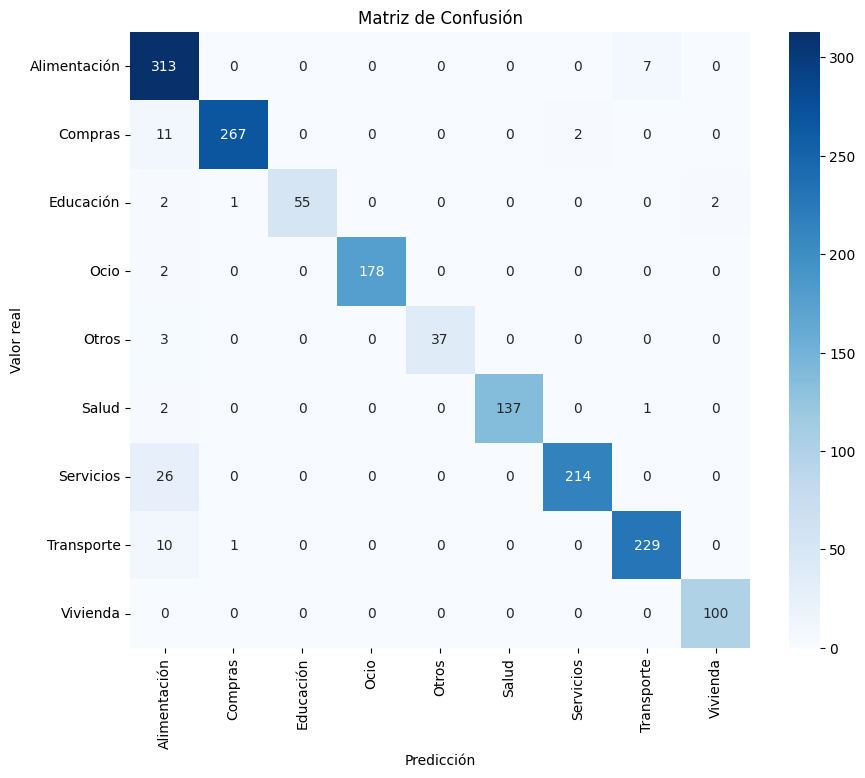

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")

plt.show()

Visualizar solamente errores


In [ ]:
errores = pd.DataFrame({
    "Real": encoder.inverse_transform(y_test),
    "Prediccion": encoder.inverse_transform(y_pred)
})

errores = errores[errores["Real"] != errores["Prediccion"]]

errores.head(20)

,Real,Prediccion
19,Servicios,Alimentación
54,Servicios,Alimentación
120,Transporte,Alimentación
157,Servicios,Alimentación
158,Compras,Alimentación
196,Compras,Alimentación
255,Servicios,Alimentación
301,Servicios,Alimentación
311,Servicios,Alimentación
319,Transporte,Alimentación


Contar las confusiones

In [ ]:
errores.groupby(
    ["Real","Prediccion"]
).size().sort_values(ascending=False)

,,0
Real,Prediccion,
Servicios,Alimentación,26
Compras,Alimentación,11
Transporte,Alimentación,10
Alimentación,Transporte,7
Otros,Alimentación,3
Salud,Alimentación,2
Educación,Alimentación,2
Compras,Servicios,2
Educación,Vivienda,2


Inspeccionar errores reales

In [ ]:
X_test_original = pd.read_csv("X_test_texto.csv").squeeze()

In [ ]:
errores = pd.DataFrame({
    "descripcion": X_test_original.reset_index(drop=True),  # Si conservaste las descripciones originales
    "real": encoder.inverse_transform(y_test),
    "prediccion": encoder.inverse_transform(y_pred)
})

errores = errores[errores["real"] != errores["prediccion"]]

errores.head(20)

,descripcion,real,prediccion
19,nequiedgardo,Servicios,Alimentación
54,mercado pagoanunciación 035817,Servicios,Alimentación
120,shellcom,Transporte,Alimentación
157,yapebrunilda,Servicios,Alimentación
158,falabellacom,Compras,Alimentación
196,applecom728422,Compras,Alimentación
255,modoamaya,Servicios,Alimentación
301,yapeleyre 966340,Servicios,Alimentación
311,nequifausto 016816,Servicios,Alimentación
319,g500614074,Transporte,Alimentación
